In [2]:
what_were_covering = {1: "Preparing and loading",
                      2: "Build model",
                      3: "Fitting the model to data(training)",
                      4: "Making predictions and evaluating a model(inference)",
                      5: "Save and reload ",
                      6: "Putting it together" }

In [3]:
import torch
from torch import nn # nn comntains all of pytorch building blocks for neural networks
import matplotlib.pyplot as plt

# Checking PyTorch version
torch.__version__

'2.9.1+cu128'

### Data Preparing and Loading 

Data can be almost anything in machine learning 
* Images of any kind
* Videos 
* Audio like songs or podcasts
* DNA
* Text
* Excel Spreadsheet

Machine learning is a game of two parts:
1. Get data into a numericsl representation.
2. Build a model to learn patterns in that numerical representation

We'd be using a linear regression formula to make a straight line with known **Parameters**.

In [4]:
# Create *known* parameters    
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1 
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y =  weight  * X + bias

X[:10], y[:10] 

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [5]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets(one of the most important concepts in ML)

Creating a training and testing data set from the data above 

In [6]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [7]:
X_train, X_test, y_train, y_test

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.3000],
         [0.3140],
        

### How to better visualise the data?

In [8]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None): 
    """
    Plots training data, test data and compare predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="testing data")

    # Are there predictions at all?
    if predictions is not None:
        #plot the predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="predictions")

    # Show the legend
    plt.legend(prop={"size":14}); 

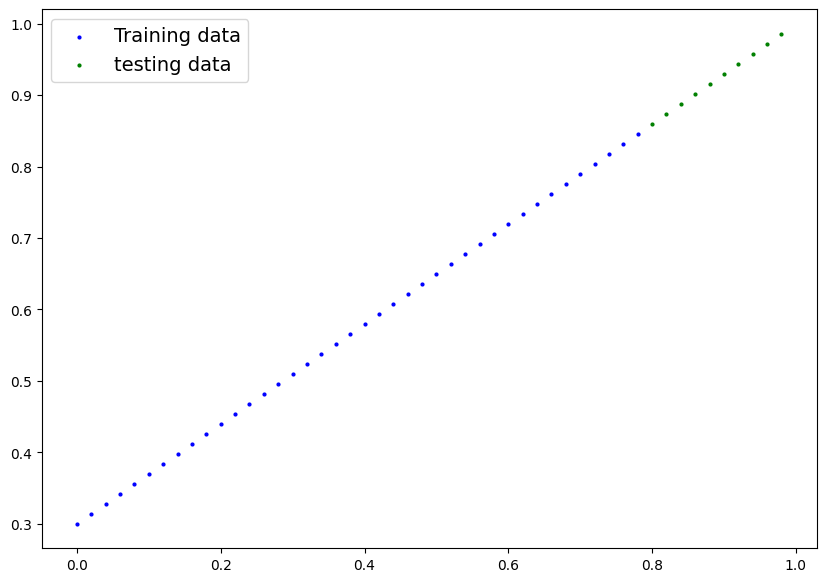

In [9]:
plot_predictions()

### 2. Build Model

My very first PyTorch model

What the Model does:
* Start with random Values (weghts and bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weights & bias values we used to create the data) 

How it does it:

Through two main algorithms:
1. Gradient descent
2. Backpropagation


In [ ]:
from torch import nn
# Create linear regression model class
class  LinearRegressionModel(nn.Module): # almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, 
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, 
                                                requires_grad=True,
                                                dtype=torch.float))
        
    # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # "x" is the input data
        return self.weight * x + self.bias # linear regression formula
    

# Pytorch Model Building essentials 

* torch.nn - contains all of the building blocks for computational graphs  (a neural network)
* torch.nn.parameter - what parameter shoukd our mode try to learn, often a pytorch layer from torch.nn will set this for us 
* torch.nn.module  - The base class for all neural network modules, if you subclass it then we should write forward()
* torch.optim -  this is where the optimisers in PyTorch lives, they will help with gradient descent
* def forward() - All nn.Module subclasses requires you to overwrite forward, this method defines what happens in teh forward computation

### Checking the contents of the PyTorch Model

We can check our model parameters or what is inside our model using .parameters(). 

In [11]:
# Create a random seed

torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [12]:
# List named parameters 
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

Last Checkout-time --> 5:29:32

### Making Prediction using `torch.inference_model()`

To check our model's predictive power, we'd like to see how well it predicts y_test based on x_test.

When we passs data through our model, it is going to run it through the 'forward()' method.


In [13]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [14]:
# Make predictions with model
with torch.inference_mode():    #Makes the predictions faster, it does this by turning off requires_grad. 
                                # so pytorch has little numbers to keep track of  
    y_preds = model_0(X_test)

# same with the inference mode, however inference mode is preferred.
#with torch.no_grad():
#    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

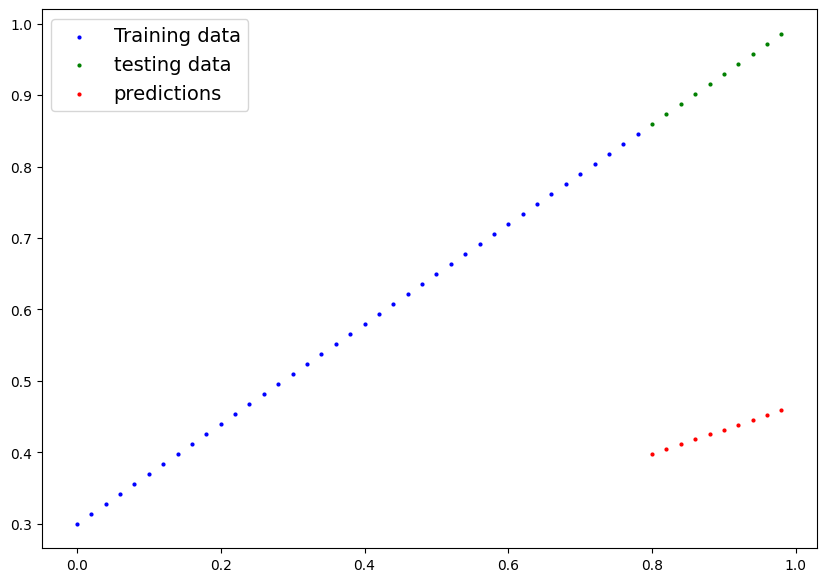

In [15]:
plot_predictions(predictions = y_preds)

### Training a Model.

The whole idea of training is for a model to move from some  *unknown* parametrs (these may be random) to some known parameters 

in other words from a poor representation of the data to a better representation of the data.

one way to meaasure how poor or how wrong our models are is to use a loss function

Things we need to train:

**Loss function:** A function to measure how wrong  the model's predictions are to the ideal outputs, lower is better

**Optimiser:** Takes into account the loss of a model and adjusts the model's parameters (e.g weight & bias in our case) to improve the loss function.
* inside the optimizer we'll have to set two parameters
*          params --> The model we want to optimize
*          lr (learning rate) - How big/small the optimiser changes the parameters with each step 

And specifically for PyTorch, we need:
* A training loop
* a testing loop  
 


In [16]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [17]:
# Checking out the model's parameters
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [18]:
# Set up a loss function
loss_fn = nn.L1Loss()

# Setup an optimiser 
optimizer = torch.optim.SGD(params = model_0.parameters(), 
                            lr = 0.01) # lr --> the  most important hyperparameter we can set

### Building a Training and a Testing loop in PyTorch

What we need in a training loop:
0. Loop through the data
1. forward pass (This involves data moving through the models `forward()` functions) -  also called forward propagation
2. Calculate the loss (compare forward pass prediction to ground truth labels)
3. Optimise zero grad 
4. loss backward - moves backwards through the networks to calculate the gradients of each of the parameters of the models with respect to the loss (**Backpropagation**)
5. Optimiser step - use the optimiser to adjust the model's performance to improve the loss (**Gradient descent**)


In [19]:
# An epoch is one loop throough the data 
epochs = 200

# Tracking different values
epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through the data
for epoch in range(epochs):
    # Set themodel to training mode
    model_0.train() # train mode in PyTorch sets all parameters that require  gradients 
    
    # 1. Forward pass 
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)
    #print(f'Loss ---> {loss}')

    # 3. Optimiser zero grad
    optimizer.zero_grad()

    # 4. Perform Backpropagation on the loss with respect to the parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step() # by default how the optimiser changes will accumulate through the  
    # loop so we have to zero them above in step 3 for the next iteration of the loop 

    # Testing 
    model_0.eval()  # It turns off different settings in the model not needed for evaluation/testing.
    with torch.inference_mode(): # Turns off gradient tracking and other things behind the scenes
        # 1. Do the forward pass again
        test_pred = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            loss_values.append(loss)
            test_loss_values.append(test_loss)
            print(f"Epoch: {epoch} | Loss : {loss} | Test loss: {test_loss}")

            # Print out Model state_dict()
            print(model_0.state_dict())

Epoch: 0 | Loss : 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict({'weight': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss : 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict({'weight': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss : 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict({'weight': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss : 0.053148526698350906 | Test loss: 0.14464017748832703
OrderedDict({'weight': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss : 0.04543796554207802 | Test loss: 0.11360953003168106
OrderedDict({'weight': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss : 0.04167863354086876 | Test loss: 0.09919948130846024
OrderedDict({'weight': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss : 0.03818932920694351 | Test loss: 0.08886633068323135
OrderedDict({'weight': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Loss : 0.0

Last checkout time : 6:25:00

In [1]:
import numpy as np
y_preds


NameError: name 'y_preds' is not defined

/tmp/ipykernel_8083/428049786.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label = "Train Loss")


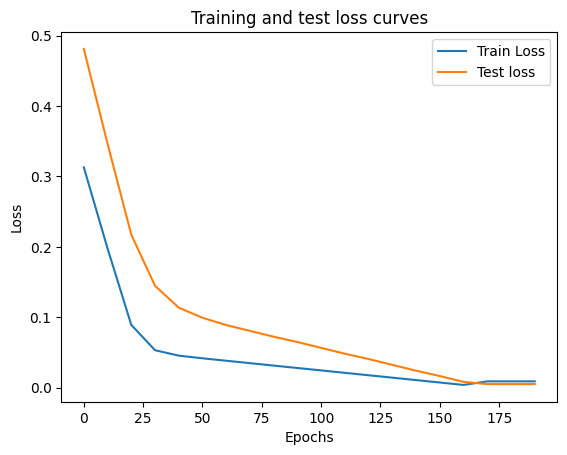

In [21]:
#plot the loss curve
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label = "Train Loss")
plt.plot(epoch_count, test_loss_values, label = "Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [22]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)


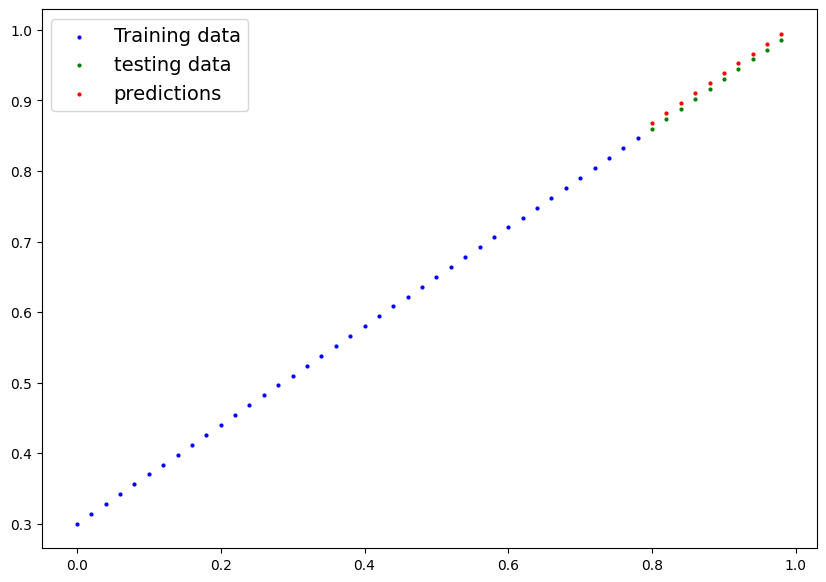

In [23]:
plot_predictions(predictions = y_preds_new)

Last checkout time ---> 7:00:59

### Saving a PyTorch model 

There are three main methods to know about saving and loading models in Pytorch.

1. `torch.save()` - allows you save a PyTorch object in python's pickle format
2. `torch.load()` - allows  you to load a saved PyTorch object 
2. `torch.nn.Module.load_state_dict() - This allows to load a model's saved dictionary 

In [24]:
# Saving the PyTorch model
from pathlib  import Path

# 1. Create Models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "first_model_pytorch_workflow.pth"
MODEL_SAVE_PATH = MODEL_PATH /MODEL_NAME

# Saving the model state dict
print(f" Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f = MODEL_SAVE_PATH)  

 Saving model to: models/first_model_pytorch_workflow.pth


In [25]:
!ls -1 models

first_model_pytorch_workflow.pth


### Loading a PyTorch model

Since we saved the model's `state_dict()` rather than the entire model, we'll create a new instance of the model class and load the saved state_dict() into that.

In [26]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [27]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

#Load the saved state_dict of model_0 (this will update the new instance with the updated parameters 
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

Last check out time ---> 7:32:51

In [28]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [29]:
# Make some predictions with our loaded models 
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [ ]:
# Compare loaded model preds with original model preds 
y_pred   


tensor([[0.2993],
        [0.3132],
        [0.3271],
        [0.3410],
        [0.3549],
        [0.3688],
        [0.3827],
        [0.3966],
        [0.4105],
        [0.4244],
        [0.4383],
        [0.4522],
        [0.4661],
        [0.4800],
        [0.4939],
        [0.5078],
        [0.5218],
        [0.5357],
        [0.5496],
        [0.5635],
        [0.5774],
        [0.5913],
        [0.6052],
        [0.6191],
        [0.6330],
        [0.6469],
        [0.6608],
        [0.6747],
        [0.6886],
        [0.7025],
        [0.7164],
        [0.7303],
        [0.7442],
        [0.7581],
        [0.7720],
        [0.7859],
        [0.7998],
        [0.8137],
        [0.8276],
        [0.8415]], grad_fn=<AddBackward0>)